In [55]:
%load_ext autoreload
%reload_ext autoreload

from helper import fitting, models, plot
from matplotlib import pyplot as plt
from alive_progress import alive_bar
import numpy as np
import pandas as pd
import sys
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
def get_dir():
    if sys.platform == "win32": # windows
        dir = r"\\svm_uhn\Coolens_Research\Isaac\Experiments\vis_test (caprese) results"
    elif sys.platform == "darwin": # mac
        dir = "/Volumes/Coolens_Research/Isaac/Experiments/vis_test (caprese) results"
    else:
        raise ValueError("Unable to get directory.")

    return dir

def import_dat(boundary = True):
    dir = get_dir()
    keys = ["depth_df", "time_df", "conc_df"]
    files = ["vis_x.csv", "vis_time.csv", "vis_conc_xt.csv"]
    if boundary:
        folder = os.path.join(dir, "boundary_true")
    else:
        folder = os.path.join(dir, "boundary_false")

    folders = {k: os.path.join(folder, v) for k, v in zip(keys, files)}
    out = {k: pd.read_csv(folders[k], dtype = float) for k in keys}

    return out

In [57]:
dat = import_dat(boundary = False)

depth, time, conc = [np.asarray(dat[k], dtype = float) for k in dat.keys()]
depth = depth.flatten()
time = time.flatten()

# Manually selected (initial drop -> interface, flattened)
depth = depth[6:30]
depth = depth - np.nanmin(depth)
conc = conc[:, 6:30]

In [58]:
dat = import_dat(boundary = True)

conc, depth, time = [np.asarray(dat[k], dtype = float) for k in sorted(dat.keys())]
depth = depth.flatten()
time = time.flatten()

depth = depth[:23]
conc = conc[:, :23]

# Manually selected (initial drop -> interface, flattened)
#depth = depth[6:24]
#depth = depth - np.nanmin(depth)
#conc = conc[:, 6:24]

In [59]:
dat = import_dat(boundary = True)

conc, depth, time = [np.asarray(dat[k], dtype = float) for k in sorted(dat.keys())]
depth = depth.flatten()
time = time.flatten()


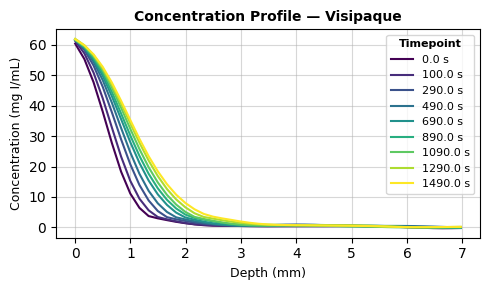

In [61]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
profs = range(0, len(time), 10)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots(figsize = (5, 3))
j = 0
for i in profs:
    ax.plot(depth, conc[i, :], label = f"{time[i]} s", color = colors[j])
    j += 1
ax.legend(title = "Timepoint", fontsize = 8, 
          title_fontproperties = {"weight": "bold", "size": 8})
ax.set_ylabel("Concentration (mg I/mL)", size = 9)
ax.set_xlabel("Depth (mm)", size = 9)
ax.grid(alpha = 0.5)
ax.set_title(f"Concentration Profile — Visipaque", 
             fontdict = {"weight": "bold", "size": 10})
plt.tight_layout()
plt.show()

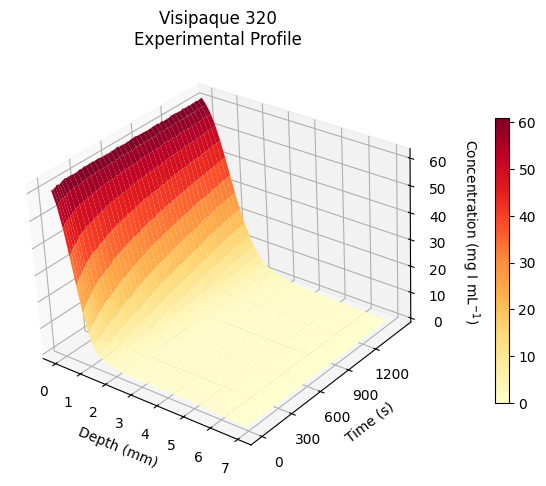

In [62]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot.plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc, 
          name = "Visipaque 320\nExperimental Profile", 
          elem = "I")
plt.tight_layout()
plt.show()

# Fitting

In [63]:
first_row = conc[:, 0]
cs_experimental = np.nanmean(first_row)

configs = []

for model in fitting.MODEL_REGISTRY:
    for fit_x0 in [False, True]:
        x0_modes_to_try = fitting.VALID_X0_MODES if fit_x0 else [None]
        for x0_mode in x0_modes_to_try:
            for cs_mode in fitting.VALID_CS_MODES:
                for d_mode in fitting.VALID_D_MODES:
                    if cs_mode == "fixed" and model == "semi-infinite":
                        cs_fixed = cs_experimental
                    elif cs_mode == "fixed" and model == "infinite":
                        cs_fixed = 2 * cs_experimental
                    else:
                        cs_fixed = None

                    cfg = fitting.FitConfig(
                        model=model,
                        fit_x0=fit_x0,
                        x0_mode=x0_mode,
                        d_mode=d_mode,
                        cs_mode=cs_mode,
                        cs_fixed=cs_fixed
                    )
                    configs.append(cfg)

print(f"Total configs: {len(configs)}")

Total configs: 36


In [64]:
results = []

with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc, depth, time, cfg)
        results.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 36/36 [100%] in 36.3s|██████████████████████████▋             | ▇▇▅ 24/36 [67%] in 21


In [66]:
rows = []

for r in results:
    cfg = r.config
    d_summary = r.d_global if cfg.d_mode == "global" else np.nanmedian(r.d_per_t)
    cs_summary = r.cs_global or r.cs_fixed if cfg.cs_mode in ["global", "fixed"] else np.nanmedian(r.cs_per_t)

    if cfg.fit_x0:
        x0_summary = np.nanmedian(r.x0_per_t) if cfg.x0_mode == "per-timepoint" else r.x0_global
    else:
        x0_summary = np.nan

    rows.append({
        "model": cfg.model,
        "fit_x0": cfg.fit_x0,
        "d_mode": cfg.d_mode,
        "cs_mode": cfg.cs_mode,
        "x0_mode": cfg.x0_mode,
        "D": d_summary,
        "Cs": cs_summary if cfg.model == "semi-infinite" else cs_summary / 2,
        "x0": x0_summary,
        "R2": r.r2_global,
        "RMSE_mean": np.nanmean(r.rmse_per_t) if r.rmse_per_t is not None else np.nan,
        "AIC": r.aic,
        "BIC": r.bic,
        "n_params": r.n_params_total
    })

summary_df = pd.DataFrame(rows)
summary_df["delta_aic"] = summary_df["AIC"] - summary_df["AIC"].min()
summary_df["delta_bic"] = summary_df["BIC"] - summary_df["BIC"].min()
summary_df.sort_values("delta_aic")
summary_df

,model,fit_x0,d_mode,cs_mode,x0_mode,D,Cs,x0,R2,RMSE_mean,AIC,BIC,n_params,delta_aic,delta_bic
0,semi-infinite,False,per-timepoint,per-timepoint,NaN,0.000957,68.117354,NaN,0.989759,1.821558,4298.077186,5280.993466,160,2.583630e+03,2.577486e+03
1,semi-infinite,False,global,per-timepoint,NaN,0.001083,66.330347,NaN,0.930455,3.768135,10224.666684,10722.268051,81,8.510219e+03,8.018761e+03
2,semi-infinite,False,per-timepoint,fixed,NaN,0.001113,61.624955,NaN,0.982220,2.374087,6065.731049,6557.189189,80,4.351283e+03,3.853682e+03
3,semi-infinite,False,global,fixed,NaN,0.001159,61.624955,NaN,0.917317,4.250833,10710.128448,10716.271675,1,8.995681e+03,8.012765e+03
4,semi-infinite,False,per-timepoint,global,NaN,0.000963,67.918660,NaN,0.989648,1.830715,4170.547300,4668.148667,81,2.456100e+03,1.964642e+03
5,semi-infinite,False,global,global,NaN,0.001022,66.773818,NaN,0.921674,3.989724,10470.236599,10482.523052,2,8.755789e+03,7.779016e+03
6,semi-infinite,True,per-timepoint,per-timepoint,per-timepoint,0.000579,46.809443,0.498000,0.995269,1.252969,1872.447658,3346.822079,240,1.580000e+02,6.433149e+02
7,semi-infinite,True,global,per-timepoint,per-timepoint,0.001030,68.901352,-0.030516,0.972148,2.599619,7334.391420,8323.450927,161,5.619944e+03,5.619944e+03
8,semi-infinite,True,per-timepoint,fixed,per-timepoint,0.000839,61.624955,0.147509,0.991004,1.706497,3846.052875,4828.969156,160,2.131605e+03,2.125462e+03
9,semi-infinite,True,global,fixed,per-timepoint,0.001016,61.624955,0.095305,0.946677,3.312275,9316.627450,9814.228817,81,7.602180e+03,7.110722e+03


**focus on global D, global x0 and fixed Cs**


In [ ]:
target_cfg = 